# CatBoost Training Pipeline
This notebook loads tracking data, processes it, and trains a CatBoost model to predict player movement.

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [17]:
import pandas as pd
import numpy as np
import catboost as cb
from pathlib import Path
from sklearn.model_selection import train_test_split

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# 1. Setup Data Directories
# Structure: train/input/file.csv and train/output/file.csv
DATA_DIR = Path("/content/drive/MyDrive/Machine Learning /train")
INPUT_DIR = DATA_DIR / "/content/drive/MyDrive/Machine Learning /train/input"
OUTPUT_DIR = DATA_DIR / "/content/drive/MyDrive/Machine Learning /train/output"

In [27]:
def get_throw_state(input_df: pd.DataFrame) -> pd.DataFrame:
    """Isolate the last frame before the pass (the 'throw state')."""
    return (
        input_df
        .sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
        .groupby(["game_id", "play_id", "nfl_id"], as_index=False)
        .tail(1)
        .rename(columns={"frame_id": "frame_id_input"})
    )

In [28]:
def normalize_direction(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize field direction so all plays move left-to-right."""
    df = df.copy()
    mask = df["play_direction"] == "left"

    # Flip coordinates for throw, future, and ball landing
    for col in ["x_throw", "x_future", "ball_land_x"]:
        df.loc[mask, col] = 120 - df.loc[mask, col]
    for col in ["y_throw", "y_future", "ball_land_y"]:
        df.loc[mask, col] = 53.3 - df.loc[mask, col]

    # Flip orientation/direction (add 180 degrees)
    df.loc[mask, "dir"] = (df.loc[mask, "dir"] + 180) % 360
    df.loc[mask, "o"]   = (df.loc[mask, "o"] + 180) % 360

    df["play_direction"] = "right"
    return df

In [29]:
def parse_height(h):
    """Convert height '6-2' to inches."""
    if isinstance(h, str) and "-" in h:
        ft, inch = h.split("-")
        try:
            return int(ft) * 12 + int(inch)
        except ValueError:
            return np.nan
    return np.nan

In [30]:
def calculate_nearest_opponent(df):
    """
    Calculates distance to the nearest player.
    If 'club' or 'team' column exists, finds nearest OPPONENT.
    If not, finds nearest HUMAN (any player) to handle missing data.
    """
    # 1. Extract coordinates
    coords = df[['x', 'y']].values

    # 2. Calculate Distance Matrix (Distance from every player to every other player)
    x_diff = coords[:, 0][:, None] - coords[:, 0]
    y_diff = coords[:, 1][:, None] - coords[:, 1]
    dists = np.sqrt(x_diff**2 + y_diff**2)

    # 3. Handle Self-Matching (Distance to self is 0, we want to ignore it)
    np.fill_diagonal(dists, np.inf)

    # 4. Try to distinguish Opponents vs Teammates
    team_col = None
    if 'club' in df.columns:
        team_col = 'club'
    elif 'team' in df.columns:
        team_col = 'team'

    if team_col:
        # If we have team info, ignore teammates
        teams = df[team_col].values
        # True where players are on DIFFERENT teams
        is_opponent = teams[:, None] != teams
        # Set teammates to infinity so min() ignores them
        dists[~is_opponent] = np.inf

    # 5. Find the minimum distance for each row
    # If no team info, this gives distance to nearest player (any team)
    min_dists = dists.min(axis=1)

    # Handle edge case: if result is still inf (e.g. player alone on field), set to a large number
    min_dists[min_dists == np.inf] = 100.0

    return pd.Series(min_dists, index=df.index)

In [31]:
def build_week_dataset(week: int) -> pd.DataFrame:
    """Load and merge input/output files for a specific week from subfolders."""
    input_path = INPUT_DIR / f"input_2023_w{week:02d}.csv"
    output_path = OUTPUT_DIR / f"output_2023_w{week:02d}.csv"

    if not input_path.exists() or not output_path.exists():
        print(f"Files not found for Week {week}. Skipping.")
        return pd.DataFrame()

    input_df  = pd.read_csv(input_path)
    output_df = pd.read_csv(output_path)

    # 1. Get the snapshot of the field at the moment of the throw
    throw_state = get_throw_state(input_df)

    # --- NEW CODE START ---
    # 2. Calculate Nearest Opponent using the full field snapshot
    # We group by game and play so players only compare against others in the same play
    print(f"  Calculating defender distances for Week {week}...", end="\r")
    nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)
    throw_state['dist_nearest_def'] = nearest_opp_dist
    # --- NEW CODE END ---

    # 3. Merge inputs with target outputs
    week_df = output_df.merge(
        throw_state,
        on=["game_id", "play_id", "nfl_id"],
        how="inner",
        suffixes=("_future", "_throw"),
    )

    week_df = week_df.rename(columns={"x_future": "x_future", "y_future": "y_future"})
    return normalize_direction(week_df)

In [32]:
# 2. Load All Data (Weeks 1-18)
print("Loading all weeks...")
all_weeks_data = []

# Assuming standard season length (adjust range if you have less data)
for w in range(1, 19):
    print(f"Processing Week {w}...", end="\r")
    df = build_week_dataset(w)
    if not df.empty:
        all_weeks_data.append(df)

print("\nMerging data...")
if all_weeks_data:
    train_all = pd.concat(all_weeks_data, ignore_index=True)
    print(f"Total dataset shape: {train_all.shape}")
else:
    print("No data loaded. Please check your folder structure.")

Loading all weeks...


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


...

/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)



Merging data...
Total dataset shape: (562936, 27)


/tmp/ipython-input-2010701415.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest_opp_dist = throw_state.groupby(['game_id', 'play_id'], group_keys=False).apply(calculate_nearest_opponent)


In [33]:
# 3. Feature Engineering
# Kinematics
train_all["t"] = train_all["frame_id"] / 10.0
train_all["dir_rad"] = np.deg2rad(train_all["dir"])
train_all["vx0"] = train_all["s"] * np.cos(train_all["dir_rad"])
train_all["vy0"] = train_all["s"] * np.sin(train_all["dir_rad"])

# Targets (Displacement)
train_all["dx_future"] = train_all["x_future"] - train_all["x_throw"]
train_all["dy_future"] = train_all["y_future"] - train_all["y_throw"]

# Context (Ball position)
train_all["dist_ball"] = np.sqrt(
    (train_all["ball_land_x"] - train_all["x_throw"])**2 +
    (train_all["ball_land_y"] - train_all["y_throw"])**2
)
train_all["angle_to_ball"] = np.arctan2(
    train_all["ball_land_y"] - train_all["y_throw"],
    train_all["ball_land_x"] - train_all["x_throw"]
)

# Player Attributes
train_all["height_in"] = train_all["player_height"].apply(parse_height)
train_all["weight_lb"] = pd.to_numeric(train_all["player_weight"], errors="coerce")
train_all["age_years"] = 2023 - pd.to_datetime(train_all["player_birth_date"], errors="coerce").dt.year

In [34]:
# 4. Filter and Prepare for ML
# Filter for relevant rows
train_ml = train_all[train_all["player_to_predict"] == True].copy()
print(f"Training set size: {train_ml.shape}")
features = [
    "t", "x_throw", "y_throw", "s", "a", "vx0", "vy0",
    "dist_ball", "angle_to_ball", "num_frames_output",
    "height_in", "weight_lb", "age_years",
    "dist_nearest_def"  # <--- Add this line
]

X = train_ml[features]
y_dx = train_ml["dx_future"]
y_dy = train_ml["dy_future"]

# Split by game_id to avoid leakage
game_ids = train_ml["game_id"].unique()
train_games, val_games = train_test_split(game_ids, test_size=0.2, random_state=42)

train_mask = train_ml["game_id"].isin(train_games)
val_mask = train_ml["game_id"].isin(val_games)

X_train, X_val = X[train_mask], X[val_mask]

Training set size: (562936, 38)


In [35]:
# 5. Train DX Model
print("Training CatBoost DX Model...")
model_dx = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    verbose=100,  # Print every 100 iterations
    allow_writing_files=False,
    task_type="CPU" # Change to "GPU" if available
)
model_dx.fit(X_train, y_dx[train_mask], eval_set=(X_val, y_dx[val_mask]), early_stopping_rounds=50)

Training CatBoost DX Model...
0:	learn: 3.6590907	test: 3.7311024	best: 3.7311024 (0)	total: 127ms	remaining: 2m 7s
100:	learn: 0.9782401	test: 1.2088079	best: 1.2088079 (100)	total: 6.2s	remaining: 55.2s
200:	learn: 0.8878324	test: 1.1763810	best: 1.1763810 (200)	total: 11.1s	remaining: 44.2s
300:	learn: 0.8338262	test: 1.1603369	best: 1.1601712 (299)	total: 17.1s	remaining: 39.7s
400:	learn: 0.7952583	test: 1.1593737	best: 1.1564933 (353)	total: 22.2s	remaining: 33.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.156493317
bestIteration = 353

Shrink model to first 354 iterations.


In [36]:
# 6. Train DY Model
print("Training CatBoost DY Model...")
model_dy = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    verbose=100,
    allow_writing_files=False,
    task_type="CPU"
)
model_dy.fit(X_train, y_dy[train_mask], eval_set=(X_val, y_dy[val_mask]), early_stopping_rounds=50)

Training CatBoost DY Model...
0:	learn: 3.4274499	test: 3.5221041	best: 3.5221041 (0)	total: 62.4ms	remaining: 1m 2s
100:	learn: 0.9837464	test: 1.0802402	best: 1.0802402 (100)	total: 5.16s	remaining: 45.9s
200:	learn: 0.8924428	test: 1.0376432	best: 1.0376432 (200)	total: 11s	remaining: 43.8s
300:	learn: 0.8420119	test: 1.0320062	best: 1.0319922 (296)	total: 15.9s	remaining: 37s
400:	learn: 0.8040827	test: 1.0202542	best: 1.0202542 (400)	total: 22s	remaining: 32.8s
500:	learn: 0.7724122	test: 1.0190878	best: 1.0181488 (468)	total: 27.1s	remaining: 27s
600:	learn: 0.7442078	test: 1.0098985	best: 1.0098905 (590)	total: 33.1s	remaining: 22s
700:	learn: 0.7214347	test: 1.0095190	best: 1.0082941 (675)	total: 38.5s	remaining: 16.4s
800:	learn: 0.6998592	test: 1.0052263	best: 1.0051332 (799)	total: 43.6s	remaining: 10.8s
900:	learn: 0.6816803	test: 1.0041103	best: 1.0036543 (868)	total: 49.8s	remaining: 5.47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.003654253
bestI

In [39]:
# 7. Final Evaluation
preds_dx = model_dx.predict(X_val)
preds_dy = model_dy.predict(X_val)

rmse = np.sqrt(np.mean((y_dx[val_mask] - preds_dx)**2 + (y_dy[val_mask] - preds_dy)**2))
print(f"\nFinal CatBoost RMSE on Validation Set: {rmse:.4f}")


Final CatBoost RMSE on Validation Set: 1.5313


Generating 2D Error Heatmap...


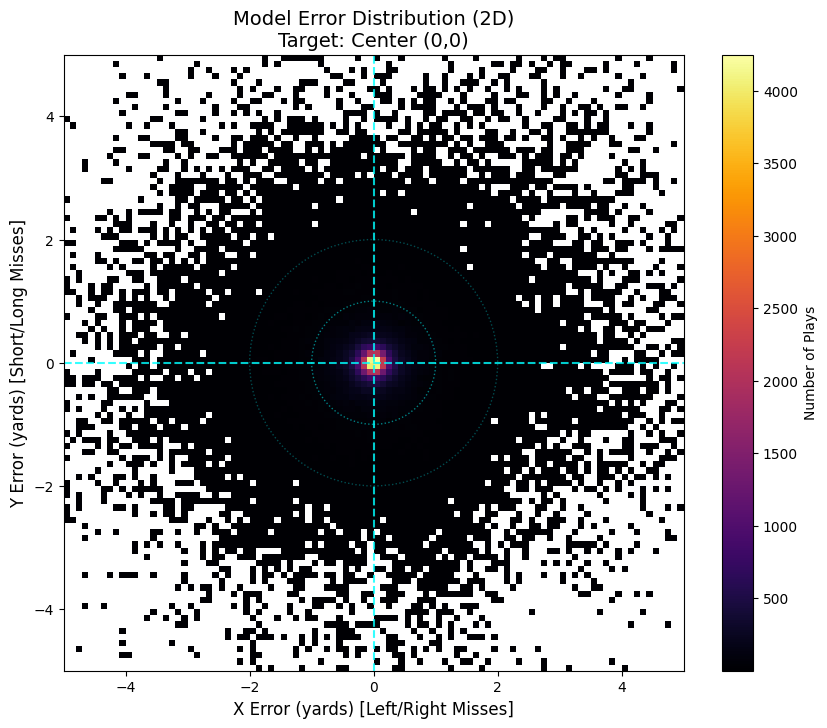

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_heatmap(y_true_dx, y_true_dy, y_pred_dx, y_pred_dy):
    """
    Plots a 2D heatmap of prediction errors.
    - Center (0,0): Perfect prediction (Red Crosshair).
    - Darker Blue: Where most of your errors are clustering.
    """
    # Calculate residuals (Difference between Prediction and Reality)
    err_x = y_pred_dx - y_true_dx
    err_y = y_pred_dy - y_true_dy

    plt.figure(figsize=(10, 8))

    # Create 2D histogram
    # Range is limited to -5 to +5 yards to focus on the important errors
    h = plt.hist2d(err_x, err_y, bins=100, cmap='inferno', range=[[-5, 5], [-5, 5]], cmin=1)

    # Add visual guides
    plt.colorbar(label='Number of Plays')
    plt.axhline(0, color='cyan', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.axvline(0, color='cyan', linestyle='--', linewidth=1.5, alpha=0.8)

    plt.title(f'Model Error Distribution (2D)\nTarget: Center (0,0)', fontsize=14)
    plt.xlabel('X Error (yards) [Left/Right Misses]', fontsize=12)
    plt.ylabel('Y Error (yards) [Short/Long Misses]', fontsize=12)

    # Add concentric circles to show error distance (1yd, 2yd, 3yd)
    circle1 = plt.Circle((0, 0), 1, color='cyan', fill=False, linestyle=':', alpha=0.5)
    circle2 = plt.Circle((0, 0), 2, color='cyan', fill=False, linestyle=':', alpha=0.3)
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)

    plt.grid(False)
    plt.show()

# --- RUN THE PLOT ---
# Ensure you have your validation predictions ready from the previous step
print("Generating 2D Error Heatmap...")
plot_error_heatmap(y_dx[val_mask], y_dy[val_mask], preds_dx, preds_dy)